# Churn Analysis
- Target column: Exited. Its a binary variable. 
    - 0 => Customer hasnt left the company
    - 1 => Customer has left the company
- Problem Statement: To identify which among the customers are likely to leave the company 

In [1]:
import numpy as np
import tensorflow as tf



In [2]:
import pandas as pd
df = pd.read_csv(r"../datasets/Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# Seperating the dependent and independent variables

In [3]:
y = df["Exited"]
X = df.drop(columns = ["Exited"])
X

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


- Features which will have no impact on whether the customer will leave the company or not are:
    - CustomerID
    - Surname
    - RowNumber
- Drop these columns
    

In [4]:
X = X.drop(columns = ["RowNumber","CustomerId", "Surname"])
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


# Encoding the categorical variables
- The categorical variables are Gender and Geography
- Label Encoder for Gender (as only 2 categories exists)
- One Hot Encoding for Geography as there is more than 2 values and it does not have any order preference

In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
X["Gender"] = label_encoder.fit_transform(X["Gender"])
X["Gender"]

0       0
1       0
2       0
3       0
4       0
       ..
9995    1
9996    1
9997    0
9998    1
9999    0
Name: Gender, Length: 10000, dtype: int64

In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
column_transformer = ColumnTransformer(transformers = [("encoder", OneHotEncoder(), [1])], remainder="passthrough")
X= column_transformer.fit_transform(X)
X

array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        1.0000000e+00, 1.0134888e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 1.1254258e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 1.1393157e+05],
       ...,
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 4.2085580e+04],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 9.2888520e+04],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 3.8190780e+04]], shape=(10000, 12))

In [7]:
X[0]

array([1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 6.1900000e+02,
       0.0000000e+00, 4.2000000e+01, 2.0000000e+00, 0.0000000e+00,
       1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0134888e+05])

- 3 Dummy columns are created due to one hot encoding as there were 3 categorical values under the Geography column

# Split the dataset into train and test

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Len of train set : {len(X_train)}")

Len of train set : 8000


# Model Building
- Sequence class is used to create sequence of layers

In [9]:
import tensorflow as tf
ann = tf.keras.Sequential()

# Hidden Layer - Adding a fully connected layer
ann.add(tf.keras.layers.Dense(
    units = 6, # units = No of Neurons
    activation = "relu" # Rectifier activation function is used for hidden layers
))

# Adding second hidden layer

In [10]:
ann.add(tf.keras.layers.Dense(
    units = 6, # units = No of Neurons
    activation = "relu" # Rectifier activation function is used for hidden layers
))

# Adding the output
- As the output is as binary the no of neurons in the hidden layer is 1
- But if the output label had 3 possible values then 3 neurons would be present in the output layer. In this case the output label must be one hot encoded and the dimension of the one hot encoded value will be 3
- In binary classification problem the output layers activation function must be sigmoid as it predicts the probability, in this case probability of a customer leaving the company

In [11]:
ann.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

- Now the brain of the model has been created

# Compiling the model

- You can choose multiple metrics to evaluate the neutral network at the same time here only accuracy is being used. To use multiple metrics pass it as [“metric1”, “metric2”…]
- When it’s a binary classification the loss function to be used is always binary_crossentropy
- For a non binary classification model the loss function will be categorical_crossentropy and activation function must not be sigmoid it must be softmax

In [12]:
ann.compile(
    optimizer= "adam",
    loss= "binary_crossentropy",
    metrics= ["accuracy"]
)

# Training
- How to decide the no of neurons required?
    - By trial and error
- You can add any number of hidden layers

In [13]:
ann.fit(
    X_train, 
    y_train, 
    batch_size = 32, # Default value
    epochs = 100 
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 272us/step - accuracy: 0.7088 - loss: 636.4683  
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 238us/step - accuracy: 0.6249 - loss: 24.9027
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 243us/step - accuracy: 0.6444 - loss: 17.8560
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 243us/step - accuracy: 0.6593 - loss: 15.7727
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 238us/step - accuracy: 0.6724 - loss: 17.6996
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 237us/step - accuracy: 0.6743 - loss: 17.2956
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 242us/step - accuracy: 0.6710 - loss: 12.7226
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 239us/step - accuracy: 0.6701 - loss: 13.0275
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 238us/step - accuracy: 0.6719 - loss: 16.2983
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - accuracy: 0.6859 - loss: 17.9281
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 242us/step - accuracy: 0.6795 - loss: 14.2646
Epoch

> Note no of epochs must not be very small as it takes sometime for the neutral network to learn
- When you are predicting against a new unseen data the preprocessing steps like normalization, encoding etc must be applied on the new unseen data too

# Predicting the results on the test dataset

In [14]:
y_pred = ann.predict(X_test)

# Converting the probability into binary values based on thresholding
y_pred = y_pred > 0.5
y_pred

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]], shape=(2000, 1))

# Confusion matrix

[[1582   25]
 [ 378   15]]


<Axes: >

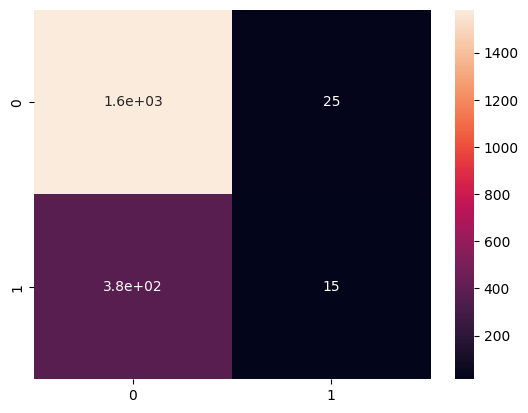

In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true=y_test, y_pred = y_pred)
print(cm)
sns.heatmap(cm, annot=True)

# Accuracy

In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true = y_test, y_pred = y_pred)
accuracy

0.7985